Dataset Shape: (8807, 12)
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  

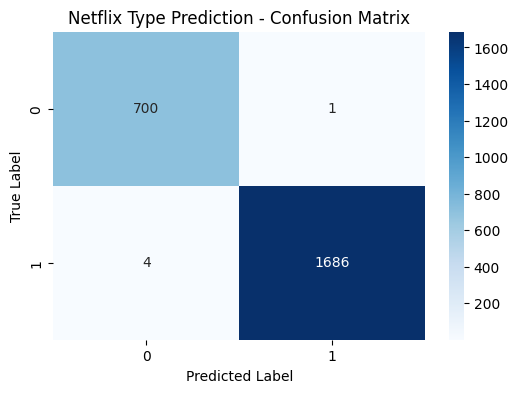

Starting Grid Search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

--- Best Parameters Found ---
{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Score: 99.86%

--- Final Tuned Model Evaluation ---
Accuracy Score: 99.75%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       701
           1       1.00      1.00      1.00      1690

    accuracy                           1.00      2391
   macro avg       1.00      1.00      1.00      2391
weighted avg       1.00      1.00      1.00      2391



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =============================
# LOAD DATASET (UPLOADED IN COLAB)
# =============================
df = pd.read_csv("netflix_titles.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# =============================
# DATA PREPROCESSING (DIFFERENT FROM ADVERTISING DATASET)
# =============================

# Keep useful columns only
data = df[['type','release_year','rating','duration','country']].copy()

# Convert duration to numeric
data['duration_num'] = data['duration'].str.extract(r'(\d+)').astype(float)

# Drop original duration column
data.drop('duration', axis=1, inplace=True)

# Drop missing values
data.dropna(inplace=True)

# Convert TARGET into binary
# Movie = 1 , TV Show = 0
data['type'] = data['type'].map({'Movie':1, 'TV Show':0})

# One-hot encode categorical features
data = pd.get_dummies(data, columns=['rating','country'], drop_first=True)

# =============================
# DEFINE FEATURES + TARGET
# =============================
X = data.drop('type', axis=1)
y = data['type']

# Train/Test Split (70/30 like your code)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

# =============================
# LOGISTIC REGRESSION MODEL
# =============================
logmodel = LogisticRegression(max_iter=2000)
logmodel.fit(X_train, y_train)

predictions = logmodel.predict(X_test)

print("\n--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, predictions)*100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

# =============================
# HEATMAP VISUALIZATION
# =============================
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, predictions),
            annot=True, fmt='d', cmap='Blues')

plt.title('Netflix Type Prediction - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ======================================================
# 🔥 HYPERPARAMETER TUNING (DIFFERENT SETUP)
# ======================================================

param_grid = {
    'C': [0.01,0.1,1,10,50],
    'penalty': ['l1','l2'],
    'solver': ['liblinear']
}

logmodel = LogisticRegression(max_iter=2000)

grid_search = GridSearchCV(
    estimator=logmodel,
    param_grid=param_grid,
    cv=5,
    verbose=1,
    scoring='accuracy'
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

print("\n--- Best Parameters Found ---")
print(grid_search.best_params_)
print(f"Best Cross-Validation Score: {grid_search.best_score_*100:.2f}%")

best_model = grid_search.best_estimator_
grid_predictions = best_model.predict(X_test)

print("\n--- Final Tuned Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, grid_predictions)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, grid_predictions))
